# COVID-19 Mexico — Exploratory Data Analysis (EDA)
**Internship:** CodeAlpha | **Task:** Task 2  
**Author:** Nouman Ali Arain | SBBU Nawabshah

## ❓ Meaningful Questions Before Analysis
1. What is the overall death rate of COVID-19 patients in Mexico?
2. Does age play a significant role in patient mortality?
3. Which comorbidities (Diabetes, Hypertension etc.) increase death risk?
4. Is there a difference in death rate between male and female patients?
5. What percentage of patients were hospitalized vs ambulatory?
6. Are there any outliers or anomalies in the age data?
7. Is there missing or inconsistent data that needs to be handled?
8. Does pneumonia presence increase the risk of death?

In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries imported!')

Libraries imported!


In [3]:
# 2. Load Dataset
df = pd.read_csv("E:\\Ineternship\\Task 2\\Covid Data.csv", low_memory=False)
print('Shape:', df.shape)
df.head()

Shape: (1048575, 21)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [4]:
# 3. Data Structure — Variables & Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [5]:
# 4. Statistical Summary
df.describe()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [6]:
# 5. Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing Values:\n', missing)

Missing Values:
 Series([], dtype: int64)


In [7]:
# 6. Duplicate Rows
print('Duplicates:', df.duplicated().sum())
df = df.drop_duplicates()
print('After removing duplicates:', df.shape)

Duplicates: 812049
After removing duplicates: (236526, 21)


In [8]:
# 7. Feature Engineering
df['DATE_DIED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce')

df['DIED']      = df['DATE_DIED'].notna().astype(int)
df['GENDER']    = df['SEX'].map({1: 'Female', 2: 'Male'})
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[0,18,30,45,60,75,120],
                         labels=['0-18','19-30','31-45','46-60','61-75','75+'],
                         right=False)

print('Death Rate:', round(df['DIED'].mean() * 100, 2), '%')

Death Rate: 12.73 %


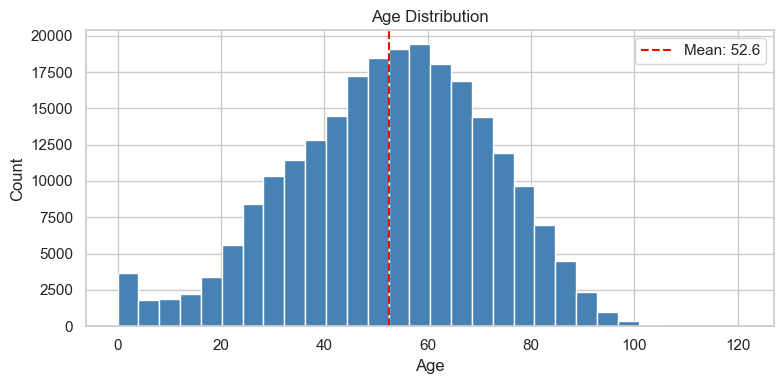

Most patients are between 30-60 years old.


In [9]:
# 8. Age Distribution
plt.figure(figsize=(8, 4))
plt.hist(df['AGE'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['AGE'].mean(), color='red', linestyle='--', label=f'Mean: {df["AGE"].mean():.1f}')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
print('Most patients are between 30-60 years old.')

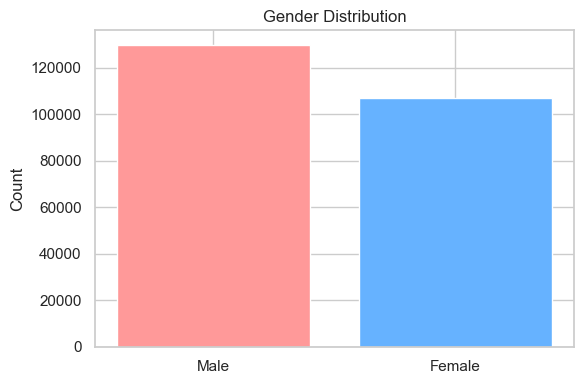

In [10]:
# 9. Gender Distribution
gc = df['GENDER'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(gc.index, gc.values, color=['#FF9999','#66B2FF'], edgecolor='white')
plt.title('Gender Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

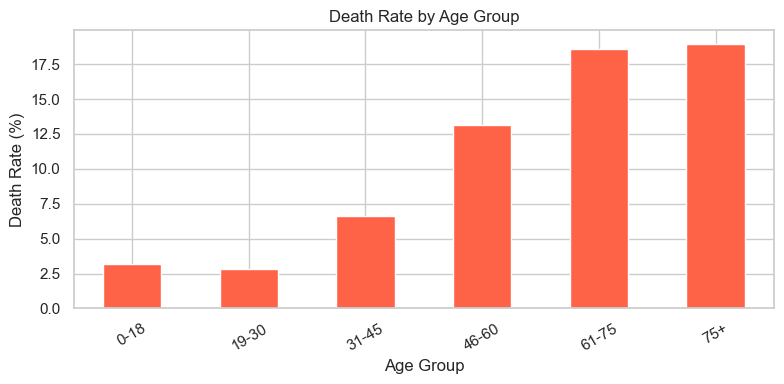

Older patients (60+) have significantly higher death rate.


In [11]:
# 10. Death Rate by Age Group
death_by_age = df.groupby('AGE_GROUP', observed=True)['DIED'].mean() * 100
plt.figure(figsize=(8, 4))
death_by_age.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Death Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Death Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print('Older patients (60+) have significantly higher death rate.')

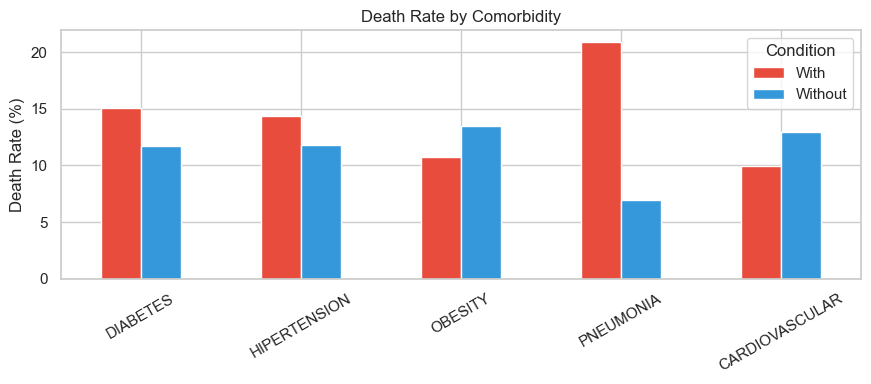

In [12]:
# 11. Comorbidities vs Death Rate
comorbidities = ['DIABETES','HIPERTENSION','OBESITY','PNEUMONIA','CARDIOVASCULAR']
available = [c for c in comorbidities if c in df.columns]

rates = {c: {'With'   : df[df[c]==1]['DIED'].mean()*100,
             'Without': df[df[c]==2]['DIED'].mean()*100} for c in available}

pd.DataFrame(rates).T.plot(kind='bar', figsize=(9, 4),
                            color=['#E74C3C','#3498DB'], edgecolor='white')
plt.title('Death Rate by Comorbidity')
plt.ylabel('Death Rate (%)')
plt.xticks(rotation=30)
plt.legend(title='Condition')
plt.tight_layout()
plt.show()

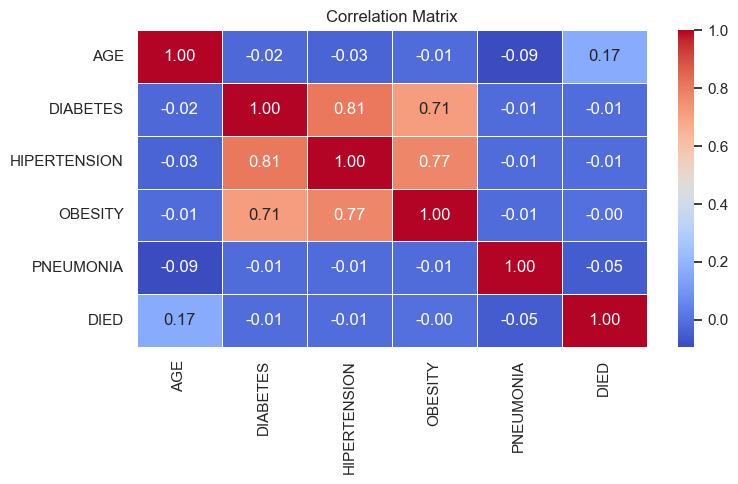

In [13]:
# 12. Correlation Heatmap
cols = [c for c in ['AGE','DIABETES','HIPERTENSION','OBESITY','PNEUMONIA','DIED'] if c in df.columns]
plt.figure(figsize=(8, 5))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Outliers: 37


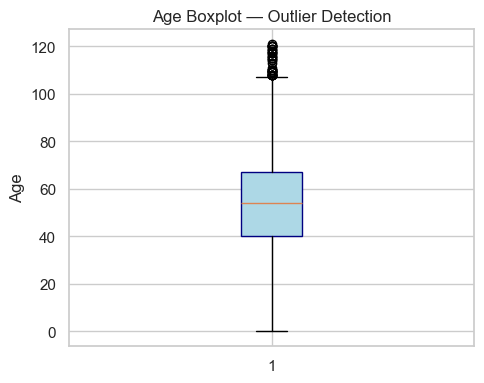

In [14]:
# 13. Outlier Detection (IQR)
Q1, Q3 = df['AGE'].quantile(0.25), df['AGE'].quantile(0.75)
IQR    = Q3 - Q1
outliers = df[(df['AGE'] < Q1-1.5*IQR) | (df['AGE'] > Q3+1.5*IQR)]
print(f'Outliers: {len(outliers):,}')

plt.figure(figsize=(5, 4))
plt.boxplot(df['AGE'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'))
plt.title('Age Boxplot — Outlier Detection')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [15]:
# 14. Hypothesis Test — Age vs Death (T-Test)
died_age     = df[df['DIED']==1]['AGE'].dropna()
survived_age = df[df['DIED']==0]['AGE'].dropna()
t_stat, p_val = stats.ttest_ind(died_age, survived_age)

print('T-Test: Age vs Death')
print(f'  Mean age (Died)    : {died_age.mean():.1f}')
print(f'  Mean age (Survived): {survived_age.mean():.1f}')
print(f'  P-value            : {p_val:.4e}')
print('  Result:', 'Reject H0 — Age significantly affects death' if p_val < 0.05 else 'Fail to reject H0')

T-Test: Age vs Death
  Mean age (Died)    : 61.0
  Mean age (Survived): 51.4
  P-value            : 0.0000e+00
  Result: Reject H0 — Age significantly affects death


In [16]:
# 15. EDA Summary
print('='*50)
print('  EDA SUMMARY — COVID-19 Mexico Dataset')
print('='*50)
print(f'Total Records : {len(df):,}')
print(f'Total Columns : {df.shape[1]}')
print(f'Total Deaths  : {df["DIED"].sum():,}')
print(f'Death Rate    : {df["DIED"].mean()*100:.2f}%')
print(f'Mean Age      : {df["AGE"].mean():.1f} years')
print()
print('Key Insights:')
print('  - Older patients (60+) have higher death rate')
print('  - Diabetes & Hypertension are top comorbidities')
print('  - Pneumonia strongly linked to death')
print('  - Males have slightly higher death rate than females')
print('='*50)

  EDA SUMMARY — COVID-19 Mexico Dataset
Total Records : 236,526
Total Columns : 24
Total Deaths  : 30,103
Death Rate    : 12.73%
Mean Age      : 52.6 years

Key Insights:
  - Older patients (60+) have higher death rate
  - Diabetes & Hypertension are top comorbidities
  - Pneumonia strongly linked to death
  - Males have slightly higher death rate than females
